# Site CF generation, BA weighting, and validation

Use 2023 weather to calculate wind and solar capacity factors (CF) for the EIA-860 2022 MISO fleet. Weight the site profiles by nameplate capacity, then compare modeled generation with EIA-930 actuals.

**Inputs:** Bundled 2022 MISO site tables, no-loss SAM configurations, installed-capacity manifest, and 2023 EIA-930 actual generation. Weather comes from matching local H5 files or HSDS.

**Requirements:** The repository environment with reV/PySAM. Missing weather files require a local HSDS service at `http://localhost:5101` with access to `nrel-pds-hsds`. Site-CF generation runs the reV models for every site and may take time.

**Outputs:** Site-weather H5 files, site-CF H5 files, weighted MISO CF CSVs, validation metrics, and a January comparison figure under `../../data_outputs/data_flow/site_cf_generation_ba_weighting_validation/`. The appendix displays an Iowa subset.

Run the code cells from top to bottom. See the [setup instructions](../../README.md#quick-start).


This example uses the EIA-860 **2022** operable fleet with 2023 weather. Production CF products use the **2024** fleet, so this notebook validates the method rather than the production fleet directly. Notebook-created H5 files, CSVs, and figures are scratch outputs.


## Setup

Load the libraries used by the HSDS download, reV generation, capacity-factor weighting, and renewable-generation validation.


In [1]:
from IPython.display import display
import json
from pathlib import Path

import h5py
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from reV.SAM.generation import PvWattsv8, WindPower
from rex import Resource

OUTPUT_DIR = Path("../../data_outputs/data_flow/site_cf_generation_ba_weighting_validation")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Shared presentation defaults; data values and plot limits are set below.
plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.titleweight": "normal",
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "legend.frameon": False,
        "grid.color": "#d1d5db",
        "grid.linewidth": 0.7,
        "grid.alpha": 0.65,
        "figure.titlesize": 16,
        "figure.titleweight": "bold",
    }
)

C:\Users\charl\miniconda3\envs\wxdata\lib\site-packages\reV\SAM\version_checker.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


## Step 1: Load regridded renewable site points

The [EIA-860 regridding notebook](eia860_regridding_methodology.ipynb) shows how EIA-860 generator rows are filtered, aggregated to renewable site coordinates, and matched to HSDS grid points for each weather source. That process produces files such as `MISO_<source>.csv` (for example, `MISO_bchrrr.csv` and `MISO_nsrdb.csv`).

The two files loaded here are `data_inputs/eia860/2022_regridded_points/MISO_bchrrr.csv` for wind and `data_inputs/eia860/2022_regridded_points/MISO_nsrdb.csv` for solar. Each row gives one renewable site, its selected HSDS `gid`, and the nameplate MW used for capacity weighting.


In [2]:
VALIDATION_YEAR = 2023

# Fleet, SAM, and validation choices for each technology.
TECHNOLOGY_CONFIG = {
    "wind": {
        "source": "bchrrr",
        "input_csv": Path("../../data_inputs/eia860/2022_regridded_points/MISO_bchrrr.csv"),
        "gid_column": "bchrrr_gid",
        "nameplate_column": "bchrrr_nameplate",
        "sam_config": Path(
            "../../data_inputs/model_parameters/sam/wind_gen_standard_no_losses_2.json"
        ),
        "actual_csv": Path("../../data_inputs/renewable_actuals/MISO_wind_2023.csv"),
        "loss_percent": 20.0,
        "loss_label": "20% loss",
        "color": "#2563eb",
    },
    "solar": {
        "source": "nsrdb",
        "input_csv": Path("../../data_inputs/eia860/2022_regridded_points/MISO_nsrdb.csv"),
        "gid_column": "nsrdb_gid",
        "nameplate_column": "nsrdb_nameplate",
        "sam_config": Path(
            "../../data_inputs/model_parameters/sam/i_pvwattsv8_single_axis_backtracking_no_losses.json"
        ),
        "actual_csv": Path("../../data_inputs/renewable_actuals/MISO_solar_2023.csv"),
        "loss_percent": 14.075660705566406,
        "loss_label": "14.1% loss",
        "color": "#f97316",
    },
}

site_points_by_technology = {}
site_summary_rows = []

for technology, config in TECHNOLOGY_CONFIG.items():
    # Summarize the regridded site CSV before downloading weather.
    # This confirms how many sites, HSDS grid points, and MW enter the total-MISO CF workflow.
    site_points = pd.read_csv(config["input_csv"])
    site_points = site_points.dropna(subset=[config["gid_column"]])
    site_points = site_points.reset_index(drop=True)
    site_points_by_technology[technology] = site_points
    site_summary_rows.append(
        {
            "technology": technology,
            "weather_source": config["source"],
            "site_rows": len(site_points),
            "unique_hsds_gids": int(site_points[config["gid_column"]].nunique()),
            "regridded_nameplate_mw": float(site_points[config["nameplate_column"]].sum()),
        }
    )

display(pd.DataFrame(site_summary_rows))

,technology,weather_source,site_rows,unique_hsds_gids,regridded_nameplate_mw
0,wind,bchrrr,305,305,29845.3
1,solar,nsrdb,539,539,4548.7


## Step 2: Stage 2023 site weather

Check local weather files, then download only those that are missing. This example stages all 8,760 hourly timestamps for 2023 at the selected wind and solar sites.

In [3]:
EXPECTED_HOURS = 8760  # Site generation and validation require the full 2023 year.

SITE_H5_DIR = OUTPUT_DIR / "site_weather_h5"
SITE_H5_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_RESOURCE_PATHS = {
    "bchrrr": "/nrel/wtk/bchrrr/v1.0.0/bchrrr_conus_2023.h5",
    "nsrdb": "/nrel/nsrdb/GOES/aggregated/v4.0.0/nsrdb_2023.h5",
}

SOURCE_VARIABLES = {
    "bchrrr": [
        "temperature_2m",
        "pressure_0m",
        "windspeed_100m",
        "winddirection_100m",
    ],
    "nsrdb": ["air_temperature", "wind_speed", "dhi", "dni", "ghi"],
}

site_weather_h5_by_technology = {}
for technology, config in TECHNOLOGY_CONFIG.items():
    filename = f"MISO_{technology}_{config['source']}_2023.h5"
    site_weather_h5_by_technology[technology] = SITE_H5_DIR / filename

### Check existing weather files

This cell checks each local H5 file before deciding whether HSDS is needed. It reads metadata and identifiers without loading weather-value arrays; any downloads happen in the next code cell.

- **Missing file:** queue it for the next download cell.
- **Matching file:** reuse it after all checks pass.
- **Validation fails:** stop with an error and leave the existing file unchanged.

Reuse requires matching grid IDs in site order, nameplate weights, required variable shapes, and all 8,760 hourly UTC timestamps for 2023. A recorded HSDS source path must also match the requested resource.

**Legacy site files:** files without source metadata can still pass the content checks, but their HSDS source version cannot be verified. The reuse message identifies this limitation.

In [4]:
technologies_to_download = []  # Only missing files are queued for the next cell.
expected_times = pd.date_range("2023-01-01", periods=EXPECTED_HOURS, freq="h", tz="UTC")

for technology, output_h5 in site_weather_h5_by_technology.items():
    config = TECHNOLOGY_CONFIG[technology]
    source = config["source"]

    # 1. Queue a missing file and skip the cache checks.
    if not output_h5.is_file():
        technologies_to_download.append(technology)
        print(
            f"{technology} ({source}): no local file; queued for HSDS download in the next code cell.\n  {output_h5.as_posix()}"
        )
        continue

    site_points = site_points_by_technology[technology]
    gids = site_points[config["gid_column"]].to_numpy(dtype=int)
    nameplate_mw = site_points[config["nameplate_column"]].to_numpy(dtype=float)

    # 2. Read metadata and identifiers without loading the weather-value arrays.
    with h5py.File(output_h5, "r") as h5_file:
        cached_times = pd.to_datetime(h5_file["time_utc"].asstr()[:], utc=True)
        # Legacy site files may lack source metadata; recorded metadata must match.
        recorded_source = h5_file.attrs.get("hsds_resource_path")
        source_matches = recorded_source is None or recorded_source == SOURCE_RESOURCE_PATHS[source]
        # Preserve grid order and nameplate weights for the later site weighting.
        points_match = np.array_equal(h5_file["gids"][:], gids)
        np.testing.assert_allclose(h5_file["nameplate_mw"][:], nameplate_mw, rtol=0, atol=1e-6)
        # Each required variable must have shape (requested hours, selected sites).
        variables_match = all(
            variable in h5_file and h5_file[variable].shape == (EXPECTED_HOURS, len(gids))
            for variable in SOURCE_VARIABLES[source]
        )
        # Reuse requires every check to pass, including the exact UTC timestamps.
        if not (
            source_matches
            and points_match
            and variables_match
            and cached_times.equals(expected_times)
        ):
            raise ValueError(
                f"Cached weather does not match this example: {output_h5.as_posix()}. Review that file before recreating it with HSDS."
            )

    # 3. Report successful reuse only after every check passes and the file closes.
    source_note = (
        "source metadata verified"
        if recorded_source is not None
        else "legacy cache; source metadata not recorded"
    )
    print(
        f"{technology} ({source}): reusing checked local H5 (hours={len(cached_times)}, sites={len(gids):,}; {source_note}).\n  {output_h5.as_posix()}"
    )

if not technologies_to_download:
    print("All weather files passed the local checks; no HSDS download is needed.")

wind (bchrrr): reusing checked local H5 (hours=8760, sites=305; legacy cache; source metadata not recorded).
  ../../data_outputs/data_flow/site_cf_generation_ba_weighting_validation/site_weather_h5/MISO_wind_bchrrr_2023.h5
solar (nsrdb): reusing checked local H5 (hours=8760, sites=539; legacy cache; source metadata not recorded).
  ../../data_outputs/data_flow/site_cf_generation_ba_weighting_validation/site_weather_h5/MISO_solar_nsrdb_2023.h5
All weather files passed the local checks; no HSDS download is needed.


### Download missing weather files

Download only queued files using the HSDS settings below. Completed files are removed from the queue, so rerunning this cell skips them. Existing files are never overwritten; if a download leaves a partial file, inspect it before retrying.

In [5]:
HSDS_ENDPOINT = "http://localhost:5101"
HSDS_API_KEY = None
HSDS_BUCKET = "nrel-pds-hsds"

if not technologies_to_download:
    print("No weather files are queued for download.")

for technology in technologies_to_download.copy():
    config = TECHNOLOGY_CONFIG[technology]
    source = config["source"]
    output_h5 = site_weather_h5_by_technology[technology]
    site_points = site_points_by_technology[technology]
    gids = site_points[config["gid_column"]].to_numpy(dtype=int)
    nameplate_mw = site_points[config["nameplate_column"]].to_numpy(dtype=float)

    print(
        f"{technology} ({source}): downloading weather for {len(gids):,} sites from HSDS.\n"
        f"  {output_h5.as_posix()}"
    )

    # 1. Open the selected HSDS resource.
    with Resource(
        SOURCE_RESOURCE_PATHS[source],
        hsds=True,
        hsds_kwargs={
            "endpoint": HSDS_ENDPOINT,
            "api_key": HSDS_API_KEY,
            "bucket": HSDS_BUCKET,
        },
    ) as resource:
        # 2. Select hourly timestamps: NSRDB is sub-hourly; BC-HRRR is already hourly.
        time_index = pd.to_datetime(resource.time_index, utc=True)
        time_positions = np.flatnonzero(time_index.minute == 0)
        selected_times = time_index[time_positions]

        # 3. Create the H5 and write identifiers and metadata.
        with h5py.File(output_h5, "x") as h5_file:
            h5_file.attrs["hsds_resource_path"] = SOURCE_RESOURCE_PATHS[source]
            h5_file.create_dataset(
                "time_utc",
                data=selected_times.strftime("%Y-%m-%dT%H:%M:%SZ").tolist(),
                dtype=h5py.string_dtype("utf-8"),
            )
            h5_file.create_dataset("gids", data=gids, dtype="i8")
            h5_file.create_dataset("nameplate_mw", data=nameplate_mw, dtype="f8")

            # 4. Write the weather variables.
            for variable in SOURCE_VARIABLES[source]:
                values = np.asarray(
                    resource[variable, :, gids],
                    dtype=np.float32,
                )[time_positions]
                h5_file.create_dataset(variable, data=values, dtype="f4")

    # 5. Mark the download complete only after the file closes.
    technologies_to_download.remove(technology)
    print(
        f"{technology} ({source}): downloaded weather H5 from HSDS "
        f"(hours={len(selected_times)}, sites={len(gids):,}).\n"
        f"  {output_h5.as_posix()}"
    )

No weather files are queued for download.


## Step 3: Convert site weather to site-level CF with reV

Run the packaged no-scalar-loss SAM configuration for every wind and solar site. Scalar losses are applied later only as validation sensitivities; they are not included in the reference capacity factors. The PVWatts input matches the production `wxdata` path and uses irradiance, air temperature, and wind speed; NSRDB surface pressure is not passed to the PV model.

The resulting H5 files retain the UTC timestamps, HSDS grid IDs, nameplate weights, and one hourly capacity-factor column per site.


In [6]:
SITE_CF_DIR = OUTPUT_DIR / "site_cf_h5"
SITE_CF_DIR.mkdir(parents=True, exist_ok=True)

site_cf_h5_by_technology = {}

for technology, config in TECHNOLOGY_CONFIG.items():
    source = config["source"]
    site_points = site_points_by_technology[technology]
    weather_h5 = site_weather_h5_by_technology[technology]
    sam_file = config["sam_config"]
    site_cf_h5 = SITE_CF_DIR / weather_h5.name
    cf_dataset = config["sam_config"].stem

    # 1. Load the technology-specific no-loss SAM configuration.
    with sam_file.open("r", encoding="utf-8") as handle:
        sam_inputs = json.load(handle)

    # 2. Read the staged validation-year weather and require a complete non-leap year.
    with h5py.File(weather_h5, "r") as weather:
        weather_time = pd.to_datetime(weather["time_utc"].asstr()[:], utc=True)
        if len(weather_time) != 8760:
            raise AssertionError(f"Expected 8,760 hourly {technology} rows for {VALIDATION_YEAR}.")
        gids = weather["gids"][:]
        nameplate_mw = weather["nameplate_mw"][:]
        site_cf_profiles = []

        print(f"Generating {technology} capacity factors with reV for {len(gids)} sites.")

        # 3. Run the appropriate reV model once for each site column.
        for site_index in range(len(gids)):
            site_row = site_points.iloc[site_index]
            site_meta = pd.Series(
                {
                    "latitude": site_row[f"{source}_lat"],
                    "longitude": site_row[f"{source}_lon"],
                    "elevation": site_row[f"{source}_elevation"],
                    "timezone": site_row[f"{source}_timezone"],
                }
            )
            if technology == "wind":
                site_weather = pd.DataFrame(
                    {
                        "temperature": weather["temperature_2m"][:, site_index],
                        "pressure": weather["pressure_0m"][:, site_index] / 101325.0,
                        "windspeed": weather["windspeed_100m"][:, site_index],
                        "winddirection": weather["winddirection_100m"][:, site_index],
                    },
                    index=weather_time,
                )
                model_class = WindPower
            else:
                site_weather = pd.DataFrame(
                    {
                        "dni": weather["dni"][:, site_index],
                        "dhi": weather["dhi"][:, site_index],
                        "ghi": weather["ghi"][:, site_index],
                        "air_temperature": weather["air_temperature"][:, site_index],
                        "wind_speed": weather["wind_speed"][:, site_index],
                    },
                    index=weather_time,
                )
                model_class = PvWattsv8

            model = model_class(
                resource=site_weather,
                meta=site_meta,
                sam_sys_inputs=sam_inputs,
                output_request=["cf_profile"],
            )
            model.run()
            site_cf_profiles.append(np.asarray(model.outputs["cf_profile"], dtype=np.float32))

    # 4. Combine the site profiles into one time-by-site matrix.
    cf_matrix = np.column_stack(site_cf_profiles)
    if cf_matrix.shape[0] != len(weather_time):
        raise AssertionError("reV output rows do not match the retained hourly timestamps.")

    # 5. Write the site-level CF matrix with its timestamps and weights.
    with h5py.File(site_cf_h5, "w") as site_cf:
        site_cf.attrs["kind"] = "renewable_site_cf"
        site_cf.attrs["technology"] = technology
        site_cf.attrs["sam_config"] = sam_file.name
        site_cf.create_dataset(
            "time_utc",
            data=weather_time.strftime("%Y-%m-%dT%H:%M:%SZ").tolist(),
            dtype=h5py.string_dtype("utf-8"),
        )
        site_cf.create_dataset("gids", data=gids, dtype="i8")
        site_cf.create_dataset("nameplate_mw", data=nameplate_mw, dtype="f8")
        site_cf.create_dataset(cf_dataset, data=cf_matrix, dtype="f4")

    site_cf_h5_by_technology[technology] = site_cf_h5
    print(f"Wrote reV site CF: {site_cf_h5.relative_to(Path('../..')).as_posix()}")

Generating wind capacity factors with reV for 305 sites.


Wrote reV site CF: data_outputs/data_flow/site_cf_generation_ba_weighting_validation/site_cf_h5/MISO_wind_bchrrr_2023.h5
Generating solar capacity factors with reV for 539 sites.


Wrote reV site CF: data_outputs/data_flow/site_cf_generation_ba_weighting_validation/site_cf_h5/MISO_solar_nsrdb_2023.h5


## Step 4: Nameplate-weight site CF into BA CF

For each hour, calculate the MISO-level capacity factor from the generated site-CF matrix:

BA_CF_t = sum(site_CF_i,t times nameplate_MW_i) / sum(nameplate_MW_i)

The weighted tables are retained in memory for the EIA-930 validation below and also written to scratch CSVs.


In [7]:
WEIGHTED_CF_DIR = OUTPUT_DIR / "weighted_ba_cf"
WEIGHTED_CF_DIR.mkdir(parents=True, exist_ok=True)

weighted_cf_summary_rows = []
weighted_cf_by_technology = {}

for technology, config in TECHNOLOGY_CONFIG.items():
    source = config["source"]
    site_cf_h5 = site_cf_h5_by_technology[technology]
    cf_dataset = config["sam_config"].stem
    weighted_cf_csv = WEIGHTED_CF_DIR / f"{site_cf_h5.stem}_weighted_cf.csv"

    # 1. Load the site CF matrix and its aligned nameplate weights.
    with h5py.File(site_cf_h5, "r") as site_cf:
        time_utc = pd.to_datetime(site_cf["time_utc"].asstr()[:], utc=True)
        site_cf_matrix = site_cf[cf_dataset][:]
        nameplate_mw = site_cf["nameplate_mw"][:]

    # 2. Nameplate-weight the site columns into one BA-level CF series.
    ba_cf = np.average(site_cf_matrix, axis=1, weights=nameplate_mw)
    ba_cf_table = pd.DataFrame(
        {
            "time_utc": time_utc,
            f"{technology}_cf": ba_cf,
        }
    )

    # 3. Retain and save the weighted series, then record its summary statistics.
    weighted_cf_by_technology[technology] = ba_cf_table
    ba_cf_table.to_csv(weighted_cf_csv, index=False, date_format="%Y-%m-%dT%H:%M:%SZ")
    print(f"Wrote {technology} weighted capacity factors: {weighted_cf_csv.as_posix()}")
    weighted_cf_summary_rows.append(
        {
            "technology": technology,
            "weather_source": source,
            "hours_written": len(ba_cf_table),
            "site_count": site_cf_matrix.shape[1],
            "nameplate_mw": float(nameplate_mw.sum()),
            "mean_ba_cf": float(ba_cf.mean()),
        }
    )

display(pd.DataFrame(weighted_cf_summary_rows))

Wrote wind weighted capacity factors: ../../data_outputs/data_flow/site_cf_generation_ba_weighting_validation/weighted_ba_cf/MISO_wind_bchrrr_2023_weighted_cf.csv


Wrote solar weighted capacity factors: ../../data_outputs/data_flow/site_cf_generation_ba_weighting_validation/weighted_ba_cf/MISO_solar_nsrdb_2023_weighted_cf.csv


,technology,weather_source,hours_written,site_count,nameplate_mw,mean_ba_cf
0,wind,bchrrr,8760,305,29845.3,0.415726
1,solar,nsrdb,8760,539,4548.7,0.193894


## Step 5: Validate modeled renewable generation against EIA-930 actuals

Convert the Step 4 capacity factors to modeled MW using the EIA-860 2022 installed wind and solar capacity, then compare them with 2023 EIA-930 actual generation. The no-loss series is the direct reV result; the scalar-loss series is included only as a validation sensitivity and is not written back to the capacity-factor files.


### Prepare aligned modeled and actual generation

In [8]:
# 1. Load the single installed-capacity record for the validation BA.
capacity_manifest = pd.read_csv("../../manifests/eia860_2022_operable_capacity_manifest.csv")
capacity_rows = capacity_manifest[capacity_manifest["BA"].eq("MISO")]
if len(capacity_rows) != 1:
    raise AssertionError("Expected exactly one MISO capacity row.")
capacity_row = capacity_rows.iloc[0]

validation_by_technology = {}

for technology, config in TECHNOLOGY_CONFIG.items():
    cf_column = f"{technology}_cf"
    actual_column = f"{technology}_actual_mw"

    # 2. Load modeled CF and actual generation.
    modeled_cf = weighted_cf_by_technology[technology]
    actual = pd.read_csv(config["actual_csv"], usecols=["time_utc", actual_column])
    actual["time_utc"] = pd.to_datetime(actual["time_utc"], utc=True)

    # 3. Align the modeled and observed series to the validation year.
    comparison = modeled_cf.merge(actual, on="time_utc", how="inner", validate="one_to_one")
    comparison = comparison[comparison["time_utc"].dt.year.eq(VALIDATION_YEAR)].reset_index(
        drop=True
    )
    if len(comparison) != 8760:
        raise AssertionError(f"Expected 8,760 aligned {technology} validation hours.")
    if comparison[[cf_column, actual_column]].isna().any().any():
        raise AssertionError(f"Aligned {technology} validation contains missing values.")

    # 4. Convert CF to MW and apply the scalar-loss sensitivity.
    installed_mw = float(capacity_row[f"Installed {technology.title()} (MW)"])
    loss_percent = config["loss_percent"]
    comparison["modeled_mw_0pct_loss"] = comparison[cf_column] * installed_mw
    comparison["modeled_mw_scalar_loss"] = comparison["modeled_mw_0pct_loss"] * (
        1 - loss_percent / 100
    )
    validation_by_technology[technology] = comparison

### Calculate and save validation metrics

Score the no-loss and scalar-loss series for each technology using the aligned hourly data above.

In [9]:
metric_rows = []

for technology, config in TECHNOLOGY_CONFIG.items():
    comparison = validation_by_technology[technology]
    actual_column = f"{technology}_actual_mw"
    loss_percent = config["loss_percent"]

    # Calculate error metrics for the no-loss and scalar-loss cases.
    cases = [
        ("0% loss", "modeled_mw_0pct_loss", 0.0),
        (config["loss_label"], "modeled_mw_scalar_loss", loss_percent),
    ]
    for case_label, modeled_column, case_loss_percent in cases:
        error = comparison[modeled_column] - comparison[actual_column]
        metric_rows.append(
            {
                "case": f"{technology.title()}: {case_label}",
                "loss_percent": case_loss_percent,
                "mae_mw": float(error.abs().mean()),
                "rmse_mw": float(np.sqrt(np.mean(error**2))),
                "bias_mw": float(error.mean()),
                "n_obs": int(error.notna().sum()),
            }
        )

# Save the technology-by-loss metric rows.
validation_metrics = pd.DataFrame(metric_rows)
validation_metrics.to_csv(
    OUTPUT_DIR / "miso_2023_renewable_loss_sensitivity_metrics.csv", index=False
)
display(validation_metrics.round(2))

,case,loss_percent,mae_mw,rmse_mw,bias_mw,n_obs
0,Wind: 0% loss,0.00,2421.16,3107.22,1937.03,8760
1,Wind: 20% loss,20.00,1247.76,1599.43,-544.46,8760
2,Solar: 0% loss,0.00,245.33,411.95,157.34,8760
3,Solar: 14.1% loss,14.08,181.97,310.04,33.20,8760


### Plot the January 2023 validation window

Plot one readable month in local Central time, showing EIA-930 actual generation, the direct no-loss modeled series, and the scalar-loss sensitivity for wind and solar.


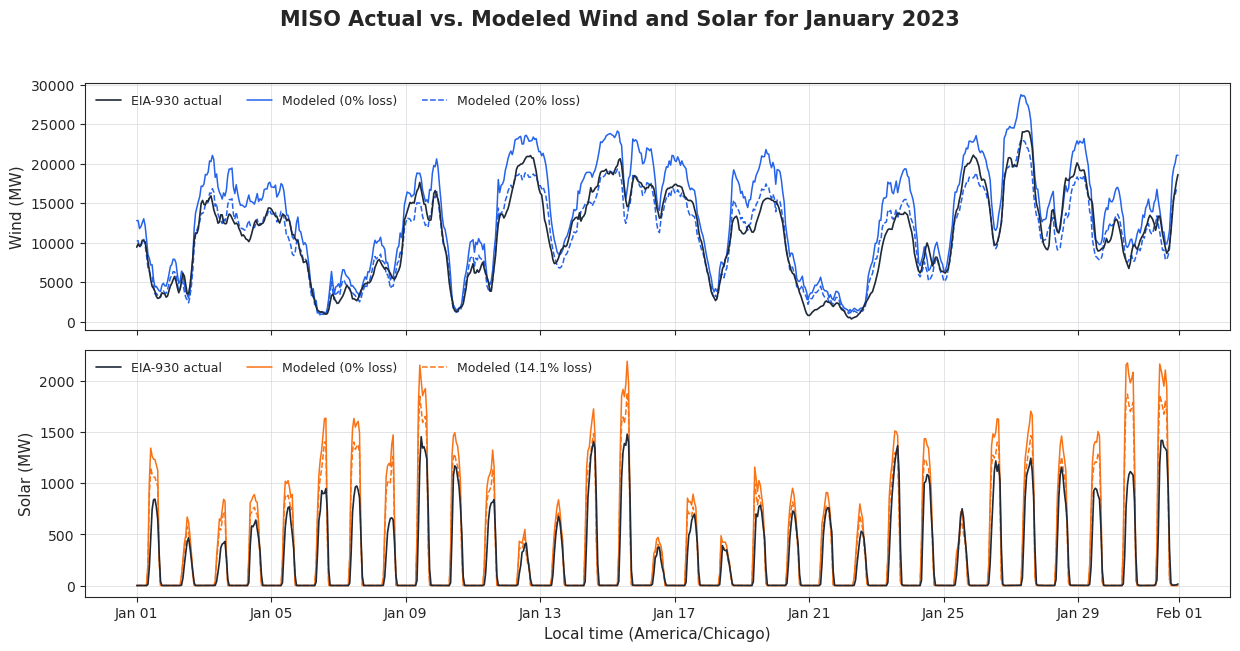

In [10]:
LOCAL_TIMEZONE = "America/Chicago"
ACTUAL_COLOR = "#1f2937"

fig, axes = plt.subplots(2, 1, figsize=(12.5, 6.6), sharex=True)

# 1. Build and plot each technology's complete January window.
for axis, (technology, config) in zip(axes, TECHNOLOGY_CONFIG.items(), strict=True):
    comparison = validation_by_technology[technology]
    local = comparison.set_index("time_utc").tz_convert(LOCAL_TIMEZONE)
    plot_data = local.loc[f"{VALIDATION_YEAR}-01"]
    actual_column = f"{technology}_actual_mw"
    axis.plot(
        plot_data.index,
        plot_data[actual_column],
        color=ACTUAL_COLOR,
        linewidth=1.2,
        label="EIA-930 actual",
        zorder=3,
    )
    axis.plot(
        plot_data.index,
        plot_data["modeled_mw_0pct_loss"],
        color=config["color"],
        linewidth=1.1,
        label="Modeled (0% loss)",
    )
    axis.plot(
        plot_data.index,
        plot_data["modeled_mw_scalar_loss"],
        color=config["color"],
        linewidth=1.1,
        linestyle="--",
        label=f"Modeled ({config['loss_label']})",
    )
    axis.set_ylabel(f"{technology.title()} (MW)")
    axis.grid(True, color="#d1d5db", linewidth=0.7, alpha=0.65)
    axis.legend(loc="upper left", frameon=False, ncol=3)

# 2. Apply the shared time-axis formatting and save the figure.
axes[-1].set_xlabel(f"Local time ({LOCAL_TIMEZONE})")
axes[-1].xaxis.set_major_locator(mdates.DayLocator(bymonthday=range(1, 32, 4), tz=LOCAL_TIMEZONE))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d", tz=LOCAL_TIMEZONE))
fig.suptitle(
    "MISO Actual vs. Modeled Wind and Solar for January 2023",
    fontsize=15,
    fontweight="bold",
)
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(
    OUTPUT_DIR / "miso_20230101_20230131_renewable_loss_sensitivity.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

## Interpretation

The no-loss and scalar-loss results use identical site profiles and capacities, so their difference isolates the stated loss assumption. Lower MAE/RMSE indicates closer agreement with EIA-930 generation; bias shows whether modeled generation is high or low.


## Appendix A: State-level aggregation demonstration

This compact extension reuses the EIA-860 2022 MISO sites and the 2023 site-CF matrices generated above. It selects sites whose regridded state is Iowa and applies the same nameplate-weighted average used for total MISO. Because the worked inputs contain only MISO sites, the result is the **MISO-contributed Iowa subset**, not a complete statewide CF product.

Complete production state CF accumulates the weighted numerator and capacity across every contributing source BA before division:

\[
CF_{k,s,t}=\frac{\sum_b\sum_{i\in(s,b)} C_i CF_{i,t}}{\sum_b\sum_{i\in(s,b)} C_i}.
\]

EIA-930 does not provide state-level renewable-generation actuals, so this appendix demonstrates the geographic aggregation and internal consistency checks; it is not a state-level validation.

In [11]:
STATE_NAME = "Iowa"
iowa_miso_cf = {}
state_summary_rows = []

for technology, config in TECHNOLOGY_CONFIG.items():
    source = config["source"]
    site_points = site_points_by_technology[technology]
    state_column = f"{source}_state"
    site_cf_h5 = site_cf_h5_by_technology[technology]
    cf_dataset = config["sam_config"].stem

    # 1. Load the site CF profiles, gids, and nameplate weights.
    with h5py.File(site_cf_h5, "r") as site_cf:
        time_utc = pd.to_datetime(site_cf["time_utc"].asstr()[:], utc=True)
        h5_gids = site_cf["gids"][:].astype(int)
        nameplate_mw = site_cf["nameplate_mw"][:]
        site_cf_matrix = site_cf[cf_dataset][:]

    # 2. Confirm that the H5 columns still match the source site table.
    metadata_gids = site_points[config["gid_column"]].to_numpy(dtype=int)
    metadata_nameplate = site_points[config["nameplate_column"]].to_numpy(dtype=float)
    if not np.array_equal(h5_gids, metadata_gids):
        raise AssertionError(f"{technology} H5 gids do not match the EIA-860 2022 site order.")
    np.testing.assert_allclose(nameplate_mw, metadata_nameplate, rtol=0, atol=1e-6)

    # 3. Select Iowa sites and nameplate-weight them into a state subset.
    keep_sites = site_points[state_column].eq(STATE_NAME).to_numpy()
    if not keep_sites.any():
        raise AssertionError(f"No {technology} sites found for {STATE_NAME}.")
    weighted_cf = np.average(
        site_cf_matrix[:, keep_sites], axis=1, weights=nameplate_mw[keep_sites]
    )
    iowa_miso_cf[technology] = pd.Series(weighted_cf, index=time_utc, name=f"{technology}_cf")
    state_summary_rows.append(
        {
            "technology": technology,
            "hours": len(weighted_cf),
            "site_count": int(keep_sites.sum()),
            "nameplate_mw": float(nameplate_mw[keep_sites].sum()),
            "mean_cf": float(weighted_cf.mean()),
        }
    )

### Align and check the Iowa subset

In [12]:
# 4. Align the technology series and validate the resulting CF bounds.
if not iowa_miso_cf["wind"].index.equals(iowa_miso_cf["solar"].index):
    raise AssertionError("Iowa wind and solar timestamps are not aligned.")
iowa_miso_cf_table = pd.concat(iowa_miso_cf.values(), axis=1)
iowa_miso_cf_table = iowa_miso_cf_table.rename_axis("time_utc")
iowa_miso_cf_table = iowa_miso_cf_table.reset_index()
if iowa_miso_cf_table["time_utc"].duplicated().any():
    raise AssertionError("Iowa timestamps must be unique.")
cf_values = iowa_miso_cf_table[["wind_cf", "solar_cf"]]
if not (cf_values.ge(0).all().all() and cf_values.le(1).all().all()):
    raise AssertionError("Iowa CF values must remain within [0, 1].")

print("MISO-contributed Iowa subset (EIA-860 2022 fleet, 2023 weather)")
display(pd.DataFrame(state_summary_rows).round(4))
print("\nSample weighted hours: January 1, 2023 at 00:00, 06:00, 12:00, and 18:00 UTC")
display(
    iowa_miso_cf_table.loc[
        iowa_miso_cf_table["time_utc"].isin(
            pd.to_datetime(
                [
                    "2023-01-01 00:00Z",
                    "2023-01-01 06:00Z",
                    "2023-01-01 12:00Z",
                    "2023-01-01 18:00Z",
                ],
                utc=True,
            )
        )
    ].round(4)
)

MISO-contributed Iowa subset (EIA-860 2022 fleet, 2023 weather)


,technology,hours,site_count,nameplate_mw,mean_cf
0,wind,8760,107,12421.3,0.4234
1,solar,8760,16,260.4,0.1984



Sample weighted hours: January 1, 2023 at 00:00, 06:00, 12:00, and 18:00 UTC


,time_utc,wind_cf,solar_cf
0,2023-01-01 00:00:00+00:00,0.4680,0.0000
6,2023-01-01 06:00:00+00:00,0.2439,0.0000
12,2023-01-01 12:00:00+00:00,0.2302,0.0000
18,2023-01-01 18:00:00+00:00,0.0371,0.2432
